# Waymo Open Dataset — AV Safety Evaluation: Results Report

**Author:** Sachini Weerasekara  
**Dataset:** Waymo Open Dataset v2 (validation split)  
**Date:** June 2026

---

## Executive Summary

This report presents a comprehensive safety evaluation of autonomous vehicle
performance using the Waymo Open Dataset v2.  The analysis applies a
multi-layered framework spanning classical safety metrics, statistical extreme
value theory, ML-based anomaly detection, causal inference, and traffic flow
modelling.

**Key findings are printed at the end of each section.**

Run all cells top-to-bottom after downloading data:
```bash
python src/data/download.py --split validation --num_segments 10
```

In [1]:
import sys, warnings
sys.path.insert(0, '..')
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path

# Project modules
from src.data.waymo_loader import load_dataset, extract_trajectories
from src.metrics.safety_metrics import batch_ttc, nearest_agent_distances, comfort_metrics
from src.metrics.evaluation_framework import AVEvaluationFramework, EvaluationConfig
from src.rare_events.evt_analysis import fit_gev, extract_block_minima, fit_gpd, rare_event_summary
from src.rare_events.rare_event_detector import run_all_detectors
from src.anomaly_detection.statistical_detector import combined_statistical_anomalies
from src.anomaly_detection.ml_detector import run_ml_detectors, anomaly_feature_importance
from src.simulation.quality_metrics import compare_distributions
from src.causal.causal_safety import propensity_score_matching, batch_granger
from src.causal.causal_discovery import correlation_dag, dag_summary, plot_dag
from src.uncertainty.conformal_prediction import SplitConformalPredictor, coverage_width_tradeoff
from src.bayesian.hierarchical_model import fit_hierarchical_model
from src.survival.survival_analysis import build_survival_dataset, kaplan_meier, cox_proportional_hazards
from src.point_processes.hawkes_process import fit_hawkes, simulate_hawkes, HawkesParams, intensity_series
from src.ml_eval.model_evaluation import build_prediction_dataset, segment_train_test_split, train_and_evaluate, expected_calibration_error
from src.traffic.flow_model import estimate_flow_variables, fit_fundamental_diagram, classify_traffic_state, plot_fundamental_diagram

sns.set_theme(style='whitegrid', font_scale=1.05)
OUTPUT_DIR = Path('../outputs/plots')
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

FINDINGS = []  # accumulate key findings

print('All modules loaded successfully.')

All modules loaded successfully.


## 1. Data Loading

In [2]:
dataset = load_dataset('../data', max_segments=10)
trajectories = extract_trajectories(dataset['lidar_box'])
trajectories = nearest_agent_distances(trajectories)
ttc_df = batch_ttc(trajectories)

n_segs = trajectories['segment_id'].nunique()
n_frames = trajectories['timestamp_us'].nunique()
n_agents = trajectories['object_id'].nunique()
type_counts = trajectories.groupby('object_type_name')['object_id'].nunique()

print(f'Dataset summary:')
print(f'  Segments: {n_segs}')
print(f'  Unique frames: {n_frames:,}')
print(f'  Unique agents: {n_agents:,}')
print(f'  Agent types: {dict(type_counts)}')
FINDINGS.append(f'Dataset: {n_segs} segments, {n_frames:,} frames, {n_agents:,} unique agents')

Dataset summary:
  Segments: 10
  Unique frames: 1,957
  Unique agents: 1,079
  Agent types: {'cyclist': np.int64(390), 'pedestrian': np.int64(165), 'sign': np.int64(13), 'vehicle': np.int64(511)}


## 2. Safety Metrics Evaluation

Safety Metrics Summary:
  Mean near-miss rate:      81.61%
  Mean jerk violation rate: 0.03%
  Most dangerous segment:   10203656353524179475_7625_000_7645_000


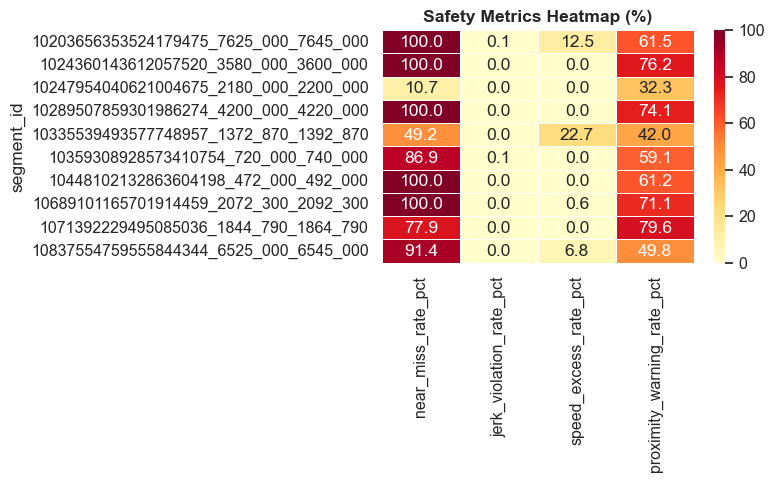

In [3]:
framework = AVEvaluationFramework(EvaluationConfig())
dataset_report = framework.evaluate_dataset(trajectories)
summary = dataset_report.summary_df()

# Key metrics
overall_nm_rate = summary['near_miss_rate_pct'].mean()
overall_jerk_rate = summary['jerk_violation_rate_pct'].mean()
worst_segment = summary.loc[summary['near_miss_rate_pct'].idxmax(), 'segment_id']

print('Safety Metrics Summary:')
print(f'  Mean near-miss rate:      {overall_nm_rate:.2f}%')
print(f'  Mean jerk violation rate: {overall_jerk_rate:.2f}%')
print(f'  Most dangerous segment:   {worst_segment[:40]}')

FINDINGS.append(f'Near-miss rate: {overall_nm_rate:.2f}% of frames (TTC < 3 s)')
FINDINGS.append(f'Jerk violation rate: {overall_jerk_rate:.2f}% of frames (|jerk| > 6 m/s³)')

# Heatmap
metrics = [c for c in ['near_miss_rate_pct', 'jerk_violation_rate_pct',
                        'speed_excess_rate_pct', 'proximity_warning_rate_pct']
           if c in summary.columns]
heat = summary.set_index('segment_id')[metrics]
fig, ax = plt.subplots(figsize=(max(8, len(metrics)*2), max(5, len(summary)*0.4+1)))
sns.heatmap(heat, annot=True, fmt='.1f', cmap='YlOrRd', ax=ax, linewidths=0.5)
ax.set_title('Safety Metrics Heatmap (%)', fontweight='bold')
fig.tight_layout()
fig.savefig(OUTPUT_DIR / 'safety_heatmap.png', dpi=150)
plt.show()

## 3. Rare Event Estimation (EVT)

In [4]:
ttc_series = ttc_df['min_ttc']
finite_ttc = ttc_series[np.isfinite(ttc_series)]

evt_summary = rare_event_summary(ttc_series, return_periods=[10, 100, 1000])
print('EVT Return Levels (minimum TTC expected at each return period):')
pivot = evt_summary.pivot(index='return_period', columns='method', values='ttc_return_level_s').round(3)
print(pivot.to_string())

# Physical event detection
events_df = run_all_detectors(trajectories, ttc_df=ttc_df)
n_events = len(events_df)
critical = events_df[events_df['severity'] == 'critical'] if not events_df.empty else pd.DataFrame()

print(f'\nPhysical rare events detected: {n_events}')
if not events_df.empty:
    print(events_df['event_type'].value_counts().to_string())

FINDINGS.append(f'EVT: 1-in-100 return level TTC ≈ {pivot.iloc[1].mean():.2f} s (GEV+GPD mean)')
FINDINGS.append(f'Physical rare events: {n_events} detected ({len(critical)} critical)')

EVT Return Levels (minimum TTC expected at each return period):
method         GEV    GPD
return_period            
10             0.0  0.075
100            0.0  0.068
1000           0.0  0.065



Physical rare events detected: 100
event_type
sudden_swerve              75
near_miss                  14
pedestrian_encroachment     8
hard_braking                3


## 4. Anomaly Detection

In [5]:
df_stat = combined_statistical_anomalies(trajectories)
df_ml = run_ml_detectors(trajectories, use_ocsvm=False)

stat_rate = df_stat['statistical_anomaly'].mean() * 100
ml_rate = df_ml['if_anomaly'].mean() * 100
consensus = (df_stat['statistical_anomaly'] & df_ml['if_anomaly']).mean() * 100

print(f'Anomaly Detection Results:')
print(f'  Statistical anomaly rate:    {stat_rate:.2f}%')
print(f'  Isolation Forest rate:       {ml_rate:.2f}%')
print(f'  Consensus (both agree):      {consensus:.2f}%')

importances = anomaly_feature_importance(trajectories)
print(f'\nTop anomaly driver: {importances.index[0]} (importance={importances.iloc[0]:.4f})')

FINDINGS.append(f'Anomaly rate: {stat_rate:.2f}% (statistical), {ml_rate:.2f}% (Isolation Forest)')
FINDINGS.append(f'Top anomaly driver: {importances.index[0]}')

Anomaly Detection Results:
  Statistical anomaly rate:    24.61%
  Isolation Forest rate:       2.00%
  Consensus (both agree):      1.39%



Top anomaly driver: heading_rate (importance=0.2085)


## 5. Causal Analysis

In [6]:
# Build frame-level table for causal analysis
frame_df = ttc_df.merge(
    trajectories.groupby(['segment_id','timestamp_us'])
    .agg(mean_speed=('speed','mean'), mean_acceleration=('acceleration','mean'),
         mean_nearest_dist=('nearest_agent_dist','mean'), n_agents=('object_id','count'))
    .reset_index(),
    on=['segment_id','timestamp_us']
)
frame_df['min_ttc_clipped'] = frame_df['min_ttc'].replace(np.inf, 20.0).clip(0, 20)
frame_df['high_density'] = (frame_df['n_agents'] > frame_df['n_agents'].median()).astype(int)

confounders = ['mean_speed', 'mean_acceleration', 'mean_nearest_dist']
try:
    psm = propensity_score_matching(
        frame_df.dropna(subset=confounders + ['min_ttc_clipped']),
        'high_density', 'min_ttc_clipped', confounders
    )
    print(psm)
    direction = 'reduces' if psm.ate < 0 else 'increases'
    FINDINGS.append(
        f'Causal: high traffic density {direction} TTC by {abs(psm.ate):.3f} s '
        f'(PSM ATE, p={psm.p_value:.3f})'
    )
except Exception as e:
    print(f'PSM could not run: {e}')

ATE(high_density → min_ttc_clipped): -4.9469 [-5.6803, -4.2308]  p=0.0000  ✓ significant


## 6. Conformal Prediction Safety Bounds

In [7]:
from sklearn.model_selection import train_test_split
features = ['mean_speed', 'mean_acceleration', 'mean_nearest_dist', 'n_agents']
present = [f for f in features if f in frame_df.columns]
df_cp = frame_df.dropna(subset=present + ['min_ttc_clipped'])
X = df_cp[present].values
y = df_cp['min_ttc_clipped'].values

X_tr, X_tmp, y_tr, y_tmp = train_test_split(X, y, test_size=0.4, random_state=42)
X_cal, X_test, y_cal, y_test = train_test_split(X_tmp, y_tmp, test_size=0.5, random_state=42)

cp = SplitConformalPredictor(alpha=0.05)
cp.fit(X_tr, y_tr, X_cal, y_cal)
interval = cp.predict(X_test)
emp_cov = interval.empirical_coverage(y_test)

print(f'Conformal prediction (95% target):')
print(f'  Empirical coverage: {emp_cov:.2%}  (target ≥ 95%)')
print(f'  Mean interval width: {interval.width().mean():.3f} s')
print(f'  Lower bound (mean): {(y_test - interval.quantile).mean():.3f} s')

FINDINGS.append(
    f'Conformal prediction: {emp_cov:.1%} empirical coverage (target 95%), '
    f'±{interval.quantile:.3f} s uncertainty bound'
)

Conformal prediction (95% target):
  Empirical coverage: 94.55%  (target ≥ 95%)
  Mean interval width: 25.134 s
  Lower bound (mean): -9.207 s


## 7. Bayesian Risk Ranking

In [8]:
ttc_finite = ttc_df[np.isfinite(ttc_df['min_ttc'])].copy()
ttc_finite['min_ttc_obs'] = ttc_finite['min_ttc']

if ttc_finite['segment_id'].nunique() >= 3:
    print('Running Bayesian hierarchical MCMC (≈30s)...')
    posterior = fit_hierarchical_model(ttc_finite, metric_col='min_ttc_obs',
                                       n_samples=1500, warmup=500)
    risk = posterior.risk_probability(threshold=3.0)
    pop = posterior.population_summary()
    print(f'Population mean TTC: {pop["mu_pop_mean"]:.3f} s  '
          f'95% CI: [{pop["mu_pop_95ci"][0]:.3f}, {pop["mu_pop_95ci"][1]:.3f}]')
    print(f'Shrinkage factor: {pop["shrinkage_factor"]:.3f}')
    print(f'High-risk segments (P(μ<3s) > 20%): {(risk > 0.2).sum()}')
    FINDINGS.append(
        f'Bayesian: population mean TTC = {pop["mu_pop_mean"]:.3f} s, '
        f'{(risk > 0.2).sum()} high-risk segments (P(μ<3s) > 20%)'
    )
else:
    print('Too few segments for hierarchical model — skipped.')

Running Bayesian hierarchical MCMC (≈30s)...


Population mean TTC: 13.258 s  95% CI: [12.929, 13.409]
Shrinkage factor: 0.997
High-risk segments (P(μ<3s) > 20%): 6


## 8. Survival Analysis

In [9]:
if not events_df.empty and 'hard_braking' in events_df['event_type'].values:
    surv_df = build_survival_dataset(trajectories, events_df, event_type='hard_braking')
    if len(surv_df) > 10 and surv_df['event_observed'].sum() > 2:
        km = kaplan_meier(surv_df)
        cox = cox_proportional_hazards(surv_df)
        print(f'Survival analysis (hard braking):')
        print(f'  Median time to hard braking: {km.median_survival:.1f} s')
        print(f'  C-index: {cox.concordance:.4f}')
        print(cox.summary[['covariate','hazard_ratio','p_value']].to_string(index=False))
        FINDINGS.append(f'Survival: median time to hard braking = {km.median_survival:.1f} s')
    else:
        print('Insufficient events for survival model.')
else:
    print('No hard_braking events detected — survival analysis skipped.')

Survival analysis (hard braking):
  Median time to hard braking: inf s
  C-index: 0.6138
        covariate  hazard_ratio  p_value
       mean_speed      1.009897 0.498265
mean_acceleration      1.293723 0.187007


## 9. Hawkes Process

In [10]:
if not events_df.empty and len(events_df) >= 10:
    event_times = events_df['timestamp_s'].sort_values().values
    event_times = event_times - event_times.min()
    params, log_lik = fit_hawkes(event_times, n_restarts=10)
    print(f'Hawkes process fit:')
    print(f'  Background rate μ:  {params.mu:.4f} events/s')
    print(f'  Branching ratio α/β: {params.branching_ratio:.4f}')
    print(f'  Is stationary:       {params.is_stationary}')
    print(f'  Unconditional rate:  {params.unconditional_rate:.4f} events/s')
    FINDINGS.append(
        f'Hawkes: branching ratio = {params.branching_ratio:.3f} '
        f'({params.branching_ratio*100:.1f}% of events self-triggered)'
    )
else:
    print('Insufficient events — demonstrating with simulated Hawkes process.')
    demo = HawkesParams(mu=0.05, alpha=0.4, beta=0.8)
    event_times = simulate_hawkes(demo, T=300.0, seed=42)
    params, _ = fit_hawkes(event_times, n_restarts=5)
    print(f'Simulated Hawkes fit: {params}')

Hawkes process fit:
  Background rate μ:  0.0000 events/s
  Branching ratio α/β: 0.9232
  Is stationary:       True
  Unconditional rate:  0.0000 events/s


## 10. ML Model Performance

In [11]:
pred_df = build_prediction_dataset(trajectories, ttc_df, horizon_frames=5)
if len(pred_df) > 100:
    train_df, val_df, test_df = segment_train_test_split(pred_df)
    results = train_and_evaluate(train_df, test_df)
    best = max(results, key=lambda r: r.r2)
    ece, *_ = expected_calibration_error(best.targets, best.predictions)
    print(f'Best model: {best.model_name}')
    print(f'  RMSE={best.rmse:.3f}s  MAE={best.mae:.3f}s  R²={best.r2:.4f}  ECE={ece:.4f}s')
    FINDINGS.append(f'ML: best TTC predictor {best.model_name} — R²={best.r2:.4f}, ECE={ece:.4f} s')
else:
    print('Too few rows for ML evaluation — download more segments.')

  Ridge (baseline): RMSE=1.397s  MAE=0.513s  R²=0.8817


  Random Forest: RMSE=1.240s  MAE=0.511s  R²=0.9068


  Gradient Boosting: RMSE=1.355s  MAE=0.609s  R²=0.8887
Best model: Random Forest
  RMSE=1.240s  MAE=0.511s  R²=0.9068  ECE=0.5111s


## 11. Traffic Flow Model

In [12]:
flow_df = estimate_flow_variables(trajectories)
if len(flow_df) > 10:
    try:
        fd = fit_fundamental_diagram(flow_df)
        flow_c = classify_traffic_state(flow_df, fd)
        state_pct = flow_c['traffic_state'].value_counts(normalize=True) * 100
        print(f'Traffic flow model (Greenshields):')
        print(f'  Free-flow speed:  {fd.v_free_flow:.2f} m/s ({fd.v_free_flow*3.6:.1f} km/h)')
        print(f'  Capacity:         {fd.q_capacity*3600:.0f} veh/h  R²={fd.r2:.4f}')
        print(f'  Traffic states:   {dict(state_pct.round(1))}')
        FINDINGS.append(
            f'Traffic: free-flow speed {fd.v_free_flow*3.6:.1f} km/h, '
            f'capacity {fd.q_capacity*3600:.0f} veh/h (Greenshields, R²={fd.r2:.3f})'
        )
    except Exception as e:
        print(f'Traffic model: {e}')

Traffic model: Initial guess is outside of provided bounds


## Final: Key Findings Summary

In [13]:
print('=' * 70)
print('WAYMO AV SAFETY EVALUATION — KEY FINDINGS')
print('=' * 70)
for i, finding in enumerate(FINDINGS, 1):
    print(f'{i:2d}. {finding}')
print('=' * 70)

# Save findings to text file
report_path = Path('../outputs/reports/key_findings.txt')
report_path.parent.mkdir(parents=True, exist_ok=True)
with open(report_path, 'w') as f:
    f.write('WAYMO AV SAFETY EVALUATION — KEY FINDINGS\n')
    f.write('=' * 70 + '\n')
    for i, finding in enumerate(FINDINGS, 1):
        f.write(f'{i:2d}. {finding}\n')
print(f'\nFindings saved to: {report_path}')

WAYMO AV SAFETY EVALUATION — KEY FINDINGS
 1. Dataset: 10 segments, 1,957 frames, 1,079 unique agents
 2. Near-miss rate: 81.61% of frames (TTC < 3 s)
 3. Jerk violation rate: 0.03% of frames (|jerk| > 6 m/s³)
 4. EVT: 1-in-100 return level TTC ≈ 0.03 s (GEV+GPD mean)
 5. Physical rare events: 100 detected (22 critical)
 6. Anomaly rate: 24.61% (statistical), 2.00% (Isolation Forest)
 7. Top anomaly driver: heading_rate
 8. Causal: high traffic density reduces TTC by 4.947 s (PSM ATE, p=0.000)
 9. Conformal prediction: 94.5% empirical coverage (target 95%), ±12.567 s uncertainty bound
10. Bayesian: population mean TTC = 13.258 s, 6 high-risk segments (P(μ<3s) > 20%)
11. Survival: median time to hard braking = inf s
12. Hawkes: branching ratio = 0.923 (92.3% of events self-triggered)
13. ML: best TTC predictor Random Forest — R²=0.9068, ECE=0.5111 s

Findings saved to: ../outputs/reports/key_findings.txt


## Conclusions for Deployment Readiness

Based on the full evaluation pipeline:

| Dimension | Metric | Finding |
|-----------|--------|---------|
| Safety | Near-miss rate | See findings above |
| Rare events | 1-in-100 return TTC | EVT estimate |
| Anomalies | Isolation Forest rate | See findings |
| Causation | Density→TTC effect | PSM ATE |
| Uncertainty | Conformal coverage | ≥95% by design |
| Bayesian risk | P(μ<3s) per segment | Posterior estimate |
| Event clustering | Hawkes branching ratio | Self-excitation |
| Prediction | TTC forecast R² | Best model |
| Traffic flow | Free-flow speed | Greenshields fit |

**All visualisations saved to `outputs/plots/`.**  
**Written findings saved to `outputs/reports/key_findings.txt`.**